### Import libraries

In [1]:
import sys
# Install OpenCV library to read video properties
!pip install opencv-python
!pip install "rembg[cpu]"

In [2]:
from google.colab import drive

import cv2
import os
from IPython.display import Video
from rembg import remove
import numpy as np

### Access videos

In [5]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
animals = os.listdir('/content/drive/MyDrive/Last Suffer/da phuong tien/video')
print(animals)

['panda', 'leopard', 'bluejay', 'tiger', 'porcupine', 'bear', 'budgie', 'kangaroo', 'giraffe', 'elephant', 'Last Suffer (1)', 'Last Suffer', 'r_frames', 'query', 'r_frames_improved_pipeline', 'multi_r_frames']


In [7]:
video_path = '/content/drive/MyDrive/Last Suffer/da phuong tien/video'

In [8]:
import os
from IPython.display import Video

# List all files and directories in the video_path
animals = os.listdir(video_path)
animals = [animal for animal in animals if not animal.startswith('Last Suffer')]
animals.remove('r_frames')
print(animals)

['panda', 'leopard', 'bluejay', 'tiger', 'porcupine', 'bear', 'budgie', 'kangaroo', 'giraffe', 'elephant', 'query', 'r_frames_improved_pipeline', 'multi_r_frames']


In [9]:
video_extensions = ('.mp4')
for animal in animals:

    sub_directory_path = os.path.join(video_path, animal)
    sub_directory_contents = os.listdir(sub_directory_path)

    for video in sub_directory_contents:
        full_video_path = os.path.join(sub_directory_path, video)

        cap = cv2.VideoCapture(full_video_path)
        if cap.isOpened():
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            print(f"Displaying video: {video} (Resolution: {width}x{height}, FPS: {fps:.2f})")
            cap.release()
        else:
            print(f"Could not open video file: {video}")

        # Display the video with a fixed width and height for consistent display size
        # display(Video(full_video_path, embed=True, height=360))

        break


Displaying video: panda2.mp4 (Resolution: 1920x1080, FPS: 30.00)
Displaying video: leo1.mp4 (Resolution: 596x336, FPS: 50.00)
Displaying video: jay1.mp4 (Resolution: 1920x1080, FPS: 30.00)
Displaying video: tiger1.mp4 (Resolution: 1920x1080, FPS: 30.00)
Displaying video: por1.mp4 (Resolution: 898x506, FPS: 29.97)
Displaying video: be1.mp4 (Resolution: 768x432, FPS: 25.00)
Displaying video: budgie1.mp4 (Resolution: 1920x1080, FPS: 30.00)
Displaying video: kangaroo1.mp4 (Resolution: 898x506, FPS: 25.00)
Displaying video: giraffe1.mp4 (Resolution: 596x336, FPS: 29.97)
Displaying video: elephant1.mp4 (Resolution: 1280x720, FPS: 60.00)
Displaying video: query_tiger1.jpg (Resolution: 275x183, FPS: 25.00)
Displaying video: r_frame_panda_panda2.png (Resolution: 512x512, FPS: 25.00)
Displaying video: r_frame_panda_panda5_f00.png (Resolution: 512x512, FPS: 25.00)


***Video lẫn lộn độ phân giải, ratio → phải chuẩn hóa***

# 1. Rút r-frame(s) + chuẩn hóa r-frame(s)

In [10]:
# def select_representative_frame(video_path, time_at_sec=1):
#     Bước 1: Trích xuất R-frame từ video tại thời điểm cố định

# def normalize_image(image, target_size=(1280, 720)):
#     Bước 2: Chuẩn hóa kích thước và tỷ lệ

# def segment_object_from_bg(image_bgr):
#     Bước 3: Tách nền dùng rembg (trả về RGBA để lấy mask từ kênh Alpha)

In [11]:
def compute_histogram(frame_bgr):
    """Tính histogram HSV (64 bins) của một frame BGR. Dùng cho H_avg và khoảng cách."""
    small = cv2.resize(frame_bgr, (160, 90))
    hsv   = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
    hist  = cv2.calcHist([hsv], [0, 1, 2], None, [8, 4, 2], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist, alpha=1, beta=0, norm_type=cv2.NORM_L1)
    return hist.flatten()


def hist_distance(h1, h2):
    """Chi-Squared distance giữa 2 histogram đã L1-normalize."""
    eps = 1e-10
    return 0.5 * float(np.sum((h1 - h2) ** 2 / (h1 + h2 + eps)))


def select_representative_frames(video_path, dist_threshold=0.15, max_k=5,
                                  window=10):
    """Trích chọn tối đa max_k r-frames từ video theo chiến lược Avg-Histogram Anchor.

    Chiến lược:
      1. Duyệt video 1 lần → thu thập tất cả frame + histogram.
      2. Tính H_avg = trung bình tất cả histogram → anchor ngữ nghĩa.
      3. Validate Frame[0]: nếu đủ gần H_avg (dist <= avg_dist_global * 1.5)
         → thêm vào candidates. Nếu không → bỏ qua Frame[0] cụ thể,
         nhưng LUÔN đảm bảo có ít nhất 1 frame bằng fallback (frame gần H_avg nhất).
      4. Duyệt video, phát hiện Candidate Zone khi
         dist(frame_curr, keyframe_last) > dist_threshold.
      5. Trong mỗi zone, chọn frame j gần H_avg nhất trong cửa sổ ±window.
      6. Giới hạn tổng ≤ max_k (ưu tiên gần H_avg, giữ thứ tự thời gian).
      7. Fallback: nếu sau tất cả vẫn không có frame nào → thêm frame gần H_avg
         nhất toàn video để LUÔN trả về ít nhất 1 frame.

    Args:
        video_path (str)      : Đường dẫn video.
        dist_threshold (float): Ngưỡng Chi-Squared để xác định vùng thay đổi.
        max_k (int)           : Số r-frame tối đa / video.
        window (int)          : Số frame lân cận mỗi phía để tìm frame tốt nhất.

    Returns:
        list[np.ndarray]: Danh sách r-frames (BGR). Rỗng chỉ nếu video lỗi.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    frames_bgr = []
    hists      = []

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames_bgr.append(frame)
        hists.append(compute_histogram(frame))
        idx += 1
        if idx >= 600:
            break
    cap.release()

    if not frames_bgr:
        return []

    # ── Bước 1: Tính H_avg ──────────────────────────────────────────────────
    hists_arr = np.array(hists, dtype=np.float32)
    h_avg     = hists_arr.mean(axis=0)
    h_avg    /= (h_avg.sum() + 1e-10)

    dists_to_avg    = [hist_distance(h, h_avg) for h in hists]
    avg_dist_global = float(np.mean(dists_to_avg))

    # Index của frame gần H_avg nhất (dùng làm fallback)
    best_overall_idx = int(np.argmin(dists_to_avg))

    # ── Bước 2: Validate Frame[0] ───────────────────────────────────────────
    # "Validate" = quyết định có đưa Frame[0] vào candidates không.
    # Dù kết quả ra sao, vẫn TIẾP TỤC xử lý phần còn lại của video.
    candidate_frame_indices = set()
    threshold_frame0 = avg_dist_global * 1.5

    if dists_to_avg[0] <= threshold_frame0:
        candidate_frame_indices.add(0)
        print(f"    [Frame0] KEPT  (dist={dists_to_avg[0]:.4f} <= {threshold_frame0:.4f})")
    else:
        # Frame[0] không đại diện (intro/logo) → bỏ qua, KHÔNG fallback ngay ở đây
        print(f"    [Frame0] SKIP  (dist={dists_to_avg[0]:.4f} >  {threshold_frame0:.4f}) — not representative")

    # ── Bước 3: Phát hiện Candidate Zones ───────────────────────────────────
    # Anchor ban đầu luôn là Frame[0] (dù nó bị skip khỏi candidates)
    # vì nó vẫn là trạng thái "hiện tại" khi video bắt đầu
    last_keyframe_hist = hists[0]

    for i in range(1, len(hists)):
        d = hist_distance(hists[i], last_keyframe_hist)
        if d > dist_threshold:
            # Tìm frame tốt nhất (gần H_avg nhất) trong cửa sổ
            lo       = max(0, i - window)
            hi       = min(len(hists) - 1, i + window)
            best_idx = min(range(lo, hi + 1), key=lambda j: dists_to_avg[j])
            candidate_frame_indices.add(best_idx)
            last_keyframe_hist = hists[best_idx]  # Cập nhật anchor

    # ── Bước 4: Fallback — đảm bảo luôn có ít nhất 1 frame ─────────────────
    if not candidate_frame_indices:
        candidate_frame_indices.add(best_overall_idx)
        print(f"    [Fallback] Không có candidate nào → chọn frame gần H_avg nhất: idx={best_overall_idx}")

    # ── Bước 5: Giới hạn max_k (ưu tiên gần H_avg, giữ thứ tự thời gian) ───
    sorted_candidates = sorted(candidate_frame_indices,
                                key=lambda j: dists_to_avg[j])
    selected_indices  = sorted(sorted_candidates[:max_k])

    print(f"    [Multi-frame] {len(candidate_frame_indices)} candidates → "
          f"{len(selected_indices)} selected (max_k={max_k})")

    return [frames_bgr[i] for i in selected_indices]


In [12]:
def normalize_image(image, target_size=(1280, 720)):
    """Chuẩn hóa khung hình: giữ đúng aspect ratio, pad viền đen, chọn interpolation đúng.

    FIX so với version cũ:
    - Giữ aspect ratio thay vì stretch méo ảnh → Shape features không bị sai
    - Chọn INTER_AREA khi thu nhỏ, INTER_CUBIC khi phóng to → texture sắc nét hơn
    - Pad viền đen để đủ kích thước target → rembg vẫn nhận đúng kích thước

    Args:
        image (numpy.ndarray): Khung hình BGR đầu vào.
        target_size (tuple): Kích thước đích (width, height). Mặc định (1280, 720).

    Returns:
        numpy.ndarray: Ảnh BGR đã chuẩn hóa, kích thước đúng target_size, không méo.
    """
    if image is None:
        print("Lỗi: Không có ảnh để chuẩn hóa!")
        return None

    target_w, target_h = target_size
    h, w = image.shape[:2]

    # Tính scale để vừa khung, giữ đúng aspect ratio
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # Chọn interpolation phù hợp: thu nhỏ dùng AREA, phóng to dùng CUBIC
    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)

    # Tạo canvas đen và paste ảnh vào chính giữa (letterbox)
    canvas = np.zeros((target_h, target_w, image.shape[2]), dtype=image.dtype)
    pad_top  = (target_h - new_h) // 2
    pad_left = (target_w - new_w) // 2
    canvas[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized

    return canvas


# 2. Tách nền

In [13]:
def segment_object_from_bg(image_bgr):
    """Tách nền dùng rembg, có validate mask và fallback.

    FIX so với version cũ:
    - Kiểm tra mask có đủ vùng object không (>= 1% diện tích)
    - Nếu mask quá rỗng → thử lại với ảnh đã tăng contrast (CLAHE)
    - Log cảnh báo để biết ảnh nào bị segmentation lỗi

    Args:
        image_bgr: Ảnh BGR đầu vào (đã normalize).

    Returns:
        tuple: (rgba_image, is_valid)
            rgba_image: Ảnh RGBA đã tách nền.
            is_valid (bool): True nếu mask hợp lệ, False nếu mask nghi ngờ lỗi.
    """
    def _run_rembg(img_bgr):
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        return remove(img_rgb)

    def _mask_coverage(rgba):
        """Tỷ lệ pixel có alpha > 0 so với toàn ảnh."""
        total = rgba.shape[0] * rgba.shape[1]
        return np.sum(rgba[:, :, 3] > 0) / total if total > 0 else 0.0

    MIN_COVERAGE = 0.01  # Ít nhất 1% diện tích phải là object

    # Lần 1: chạy rembg trực tiếp
    rgba = _run_rembg(image_bgr)
    coverage = _mask_coverage(rgba)

    if coverage >= MIN_COVERAGE:
        return rgba, True

    # Lần 2 (fallback): tăng contrast bằng CLAHE trước khi chạy lại
    print(f"    [WARN] Mask quá rỗng (coverage={coverage:.3f}), thử CLAHE fallback...")
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab_clahe = cv2.merge([clahe.apply(l), a, b])
    enhanced = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    rgba2 = _run_rembg(enhanced)
    coverage2 = _mask_coverage(rgba2)

    if coverage2 >= MIN_COVERAGE:
        print(f"    [OK] CLAHE fallback thành công (coverage={coverage2:.3f})")
        return rgba2, True

    # Vẫn thất bại → trả về nhưng đánh dấu invalid
    print(f"    [ERROR] Segmentation thất bại hoàn toàn (coverage={coverage2:.3f}), ảnh này sẽ bị loại!")
    return rgba2, False


In [14]:
def normalize_image_on_roi(rgba_image, target_size=(512, 512)):
    """Chuẩn hóa r-frame SAU KHI đã segment: crop ROI theo mask alpha,
    resize về target_size giữ đúng aspect ratio, pad viền đen.

    Cải tiến so với pipeline cũ (normalize trước segment):
    - rembg không bị nhiễu bởi letterbox padding viền đen
    - Feature extraction làm việc trên ROI thực của vật thể, không có vùng padding vô nghĩa
    - target_size nhỏ hơn (512x512) vì đã crop sát object → tiết kiệm bộ nhớ

    Args:
        rgba_image (numpy.ndarray): Ảnh RGBA đã tách nền.
        target_size (tuple): Kích thước đích (width, height). Mặc định (512, 512).

    Returns:
        numpy.ndarray: Ảnh RGBA đã crop ROI và chuẩn hóa kích thước.
        Trả về None nếu mask rỗng.
    """
    if rgba_image is None:
        return None

    # Crop ROI theo bounding box của mask alpha
    mask_alpha = rgba_image[:, :, 3]
    coords = cv2.findNonZero(mask_alpha)
    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)
    if w == 0 or h == 0:
        return None

    # Thêm padding 10% quanh bounding box để tránh crop quá sát
    pad_x = int(w * 0.10)
    pad_y = int(h * 0.10)
    img_h, img_w = rgba_image.shape[:2]
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(img_w, x + w + pad_x)
    y2 = min(img_h, y + h + pad_y)

    roi = rgba_image[y1:y2, x1:x2]  # RGBA crop

    target_w, target_h = target_size
    roi_h, roi_w = roi.shape[:2]

    # Giữ aspect ratio khi resize
    scale = min(target_w / roi_w, target_h / roi_h)
    new_w, new_h = int(roi_w * scale), int(roi_h * scale)
    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
    resized = cv2.resize(roi, (new_w, new_h), interpolation=interp)

    # Tạo canvas trong suốt và paste ROI vào chính giữa
    canvas = np.zeros((target_h, target_w, 4), dtype=rgba_image.dtype)
    pad_top  = (target_h - new_h) // 2
    pad_left = (target_w - new_w) // 2
    canvas[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized

    return canvas


# 3. Rút feature

## 3.1. Color feature

### 3.1.1. Dùng Color Moments (9D) + Quantized HSV (128D)

In [15]:
import cv2
import numpy as np

def extract_color_features_128bin(rgba_image):
    """Trích xuất Color Moments (9D) + Quantized HSV Histogram (192D). Tổng: 201 chiều.

    FIX so với version cũ:
    - Hue (kênh H) dùng circular mean thay vì arithmetic mean → đúng với màu sắc
    - Tăng bin Hue từ 8 lên 12 (12×4×4=192) → phân biệt tốt hơn xanh lá vs xanh lam
    - Histogram KHÔNG bị normalize 2 lần (L1 normalize ở đây, KHÔNG MinMaxScale ở bước sau)
    - color_hist_len cập nhật = 12*4*4 = 192
    """
    mask = rgba_image[:, :, 3] > 0
    mask_uint8 = mask.astype(np.uint8)
    rgb_image = rgba_image[:, :, :3].copy()
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)

    object_pixels = hsv_image[mask]
    COLOR_HIST_BINS = [12, 4, 4]  # 12×4×4 = 192 bins
    n_hist = COLOR_HIST_BINS[0] * COLOR_HIST_BINS[1] * COLOR_HIST_BINS[2]

    if len(object_pixels) == 0:
        return [0.0] * (9 + n_hist)

    # --- PHẦN 1: COLOR MOMENTS (9 Chiều) ---
    moments = []
    for i in range(3):
        channel = object_pixels[:, i].astype(np.float32)

        if i == 0:
            # Kênh HUE là circular → dùng circular mean/std
            # Chuyển sang radian [0, 2π], tính circular stats, chuyển lại
            angles = channel / 180.0 * np.pi * 2  # H ∈ [0,180] → [0, 2π]
            sin_mean = np.mean(np.sin(angles))
            cos_mean = np.mean(np.cos(angles))
            circular_mean_rad = np.arctan2(sin_mean, cos_mean)
            mean_val = (circular_mean_rad % (2 * np.pi)) / (2 * np.pi) * 180  # trả về [0,180]
            # Circular std (Mardia's measure)
            R = np.sqrt(sin_mean**2 + cos_mean**2)
            std_val = np.sqrt(-2 * np.log(R + 1e-9)) / (2 * np.pi) * 180
            # Circular skewness
            diff = angles - circular_mean_rad
            diff = (diff + np.pi) % (2 * np.pi) - np.pi  # wrap to [-π, π]
            skew = np.mean(np.sin(2 * diff))
        else:
            mean_val = np.mean(channel)
            std_val  = np.std(channel)
            if std_val > 1e-6:
                skew = np.mean((channel - mean_val)**3) / (std_val**3)
            else:
                skew = 0.0

        moments.extend([float(mean_val), float(std_val), float(skew)])

    # --- PHẦN 2: 3D HISTOGRAM (12×4×4 = 192 Chiều) ---
    hist = cv2.calcHist(
        [hsv_image], [0, 1, 2], mask_uint8,
        COLOR_HIST_BINS,
        [0, 180, 0, 256, 0, 256]
    )
    # L1-normalize (probability density). KHÔNG scale thêm ở bước combine.
    hist_norm = cv2.normalize(hist, None, alpha=1, beta=0, norm_type=cv2.NORM_L1).flatten()

    return moments + hist_norm.tolist()


## 3.2. Texture feature

In [16]:
from skimage.feature import local_binary_pattern
import cv2
import numpy as np

def extract_ulbp_features(rgba_image):
    """Trich xuat Uniform LBP (56D) lam dac trung texture.

    Mo ta:
    - LBP voi P=8 lang gieng, R=1 (ban kinh 1px)
    - Chi giu 56 patterns co cau truc: k=1..7 bit-1 lien tiep x 8 phep quay
      (loai bo all-zeros, all-ones, va patterns khong dong nhat)
    - Histogram 56D duoc L1-normalize tren vung object (theo mask alpha)
    - Ap dung tren kenh Value (V) cua HSV de bat bien voi mau sac

    Args:
        rgba_image (numpy.ndarray): Anh RGBA da tach nen.

    Returns:
        list: Vector 56 chieu da L1-normalize.
    """
    # -- Cat ROI tu bounding box cua mask alpha --
    mask_alpha = rgba_image[:, :, 3]
    coords = cv2.findNonZero(mask_alpha)
    if coords is None:
        return [0.0] * 56
    x, y, w, h = cv2.boundingRect(coords)
    if w == 0 or h == 0:
        return [0.0] * 56

    object_roi = rgba_image[y:y+h, x:x+w]
    target_size = (256, 256)
    normalized_roi = cv2.resize(object_roi, target_size, interpolation=cv2.INTER_AREA)

    # Dung kenh V (Value) cua HSV -- nhat quan voi Tamura cu
    hsv = cv2.cvtColor(normalized_roi[:, :, :3], cv2.COLOR_RGB2HSV)
    gray = hsv[:, :, 2]
    normalized_mask = normalized_roi[:, :, 3] > 0

    if not np.any(normalized_mask):
        return [0.0] * 56

    # -- Tinh LBP raw (method='default' -> gia tri 0-255) --
    lbp = local_binary_pattern(gray, P=8, R=1, method='default').astype(np.int32)

    # -- Xay dung lookup table: pattern 0-255 -> bin index 0-55 (hoac -1) --
    # Uniform pattern: so lan chuyen bit (0->1 hoac 1->0) trong chuoi tron <= 2
    # 56 bins = 7 nhom (k=1..7 bit-1) x 8 phep quay moi nhom
    def _count_transitions(n, P=8):
        bits = [(n >> i) & 1 for i in range(P)]
        return sum(1 for i in range(P) if bits[i] != bits[(i + 1) % P])

    lookup = np.full(256, -1, dtype=np.int32)
    bin_idx = 0
    for k in range(1, 8):          # k = 1..7 bit-1 lien tiep
        for pattern in range(256):
            if bin(pattern).count('1') == k and _count_transitions(pattern) == 2:
                lookup[pattern] = bin_idx
                bin_idx += 1
    # Kiem tra: bin_idx phai == 56

    # -- Tinh histogram 56D chi tren pixels trong mask --
    valid_lbp = lbp[normalized_mask]
    hist = np.zeros(56, dtype=np.float32)
    for val in valid_lbp:
        b = lookup[val]
        if b >= 0:
            hist[b] += 1

    # L1-normalize
    total = hist.sum()
    if total > 0:
        hist /= total

    return hist.tolist()


## 3.2. Shapes feature

In [17]:
def extract_shape_features(rgba_image):
    """
    Trích xuất 7 đặc trưng hình dạng Hu Moments từ mặt nạ vật thể.

    Chiến lược: Sử dụng kênh Alpha để lấy hình dáng (silhouette) của con vật.
    Đặc trưng này bất biến với tịnh tiến, xoay và đặc biệt là TỶ LỆ (Scale).

    Args:
        rgba_image (numpy.ndarray): Ảnh RGBA đã tách nền.

    Returns:
        list: Vector 7 chiều Hu Moments đã được chuẩn hóa qua Log Scale.
    """
    # 1. Lấy kênh Alpha làm mặt nạ nhị phân (Binary Mask)
    # Đây là bước quan trọng nhất để lấy hình dáng thuần túy
    mask = rgba_image[:, :, 3]

    # Kiểm tra nếu mask trống (không có vật thể)
    if np.sum(mask) == 0:
        return [0.0] * 7

    # 2. Tính toán các Moment cơ bản (Moments)
    # Moments mô tả sự phân bố pixel trong không gian 2D
    moments = cv2.moments(mask)

    # 3. Tính toán 7 chỉ số Hu Moments
    # Các chỉ số này được kết hợp từ moments cơ bản để đạt tính bất biến
    hu_moments = cv2.HuMoments(moments).flatten()

    # 4. Chuẩn hóa Log Scale (Log Transformation)
    # Vì Hu Moments có biên độ rất nhỏ (ví dụ 10^-10), ta cần lấy log
    # Công thức: h_i = -sign(h_i) * log10(abs(h_i))
    hu_log = []
    for h in hu_moments:
        if h != 0:
            # Dùng trị tuyệt đối để lấy log, sau đó trả lại dấu
            val = -np.sign(h) * np.log10(np.abs(h))
        else:
            val = 0.0
        hu_log.append(float(val))

    return hu_log

## 3.3. HOG feature (576D → PCA → 64D)

In [18]:
from skimage.feature import hog as skimage_hog
import cv2
import numpy as np

def extract_hog_features_raw(rgba_image):
    """Trích xuất HOG features thô (576D) từ vùng object.

    Cấu hình:
    - Crop ROI theo bounding box của mask alpha, resize về 64×64
    - HOG: orientations=9, pixels_per_cell=(8,8), cells_per_block=(1,1)
    - Kết quả: 8×8 cells × 9 orientations = 576D
    - Áp dụng trên kênh Grayscale; sẽ được giảm chiều bằng PCA → 64D sau.

    Args:
        rgba_image (numpy.ndarray): Ảnh RGBA đã tách nền.

    Returns:
        numpy.ndarray: Vector 576 chiều (float32), toàn 0 nếu mask rỗng.
    """
    HOG_DIM = 576

    mask_alpha = rgba_image[:, :, 3]
    coords = cv2.findNonZero(mask_alpha)
    if coords is None:
        return np.zeros(HOG_DIM, dtype=np.float32)
    x, y, w, h = cv2.boundingRect(coords)
    if w == 0 or h == 0:
        return np.zeros(HOG_DIM, dtype=np.float32)

    object_roi = rgba_image[y:y+h, x:x+w]

    # Resize ROI về 64×64 để đảm bảo đúng 576D
    roi_resized = cv2.resize(object_roi[:, :, :3], (64, 64), interpolation=cv2.INTER_AREA)

    # Chuyển sang Grayscale (nhất quán với LBP)
    gray = cv2.cvtColor(roi_resized, cv2.COLOR_RGB2GRAY)

    # HOG: 8×8 cells (grid 8×8), 1×1 block, 9 orientations → 576D
    hog_feat = skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(1, 1),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return hog_feat.astype(np.float32)


# 4. Main

## 4.1. R-FRAME extraction, normalization, segmentation, and saving

In [19]:
import os
import cv2

# Pipeline đa r-frame: select_representative_frames → segment → normalize_image_on_roi
# Lưu vào folder 'multi_r_frames'; tên file gồm cả frame index để phân biệt
multi_r_frames_dir = os.path.join(video_path, 'multi_r_frames')
os.makedirs(multi_r_frames_dir, exist_ok=True)

# r_frames_dir trỏ về folder mới → các cell feature extraction bên dưới tự động dùng
r_frames_dir = multi_r_frames_dir

failed_segmentations = []
total_saved = 0

for animal in animals:
    sub_directory_path = os.path.join(video_path, animal)
    if not os.path.isdir(sub_directory_path):
        continue

    sub_directory_contents = os.listdir(sub_directory_path)
    print(f"\nProcessing animal category: {animal}")

    for video_name in sub_directory_contents:
        if video_name.endswith(video_extensions):
            full_video_path = os.path.join(sub_directory_path, video_name)
            video_stem      = os.path.splitext(video_name)[0]
            print(f"  - Processing {video_name}...")

            # Bước 1: Chọn tối đa max_k=5 r-frames (chiến lược Avg-Histogram Anchor)
            r_frames_bgr = select_representative_frames(full_video_path, max_k=5)

            if not r_frames_bgr:
                print(f"    -> Could not extract any frame: {video_name}")
                failed_segmentations.append(f"{animal}/{video_name} [no frame]")
                continue

            saved_this_video = 0
            for frame_idx, r_frame_bgr in enumerate(r_frames_bgr):
                # Bước 2: Segment trực tiếp trên ảnh gốc
                segmented_rgba, is_valid = segment_object_from_bg(r_frame_bgr)

                if not is_valid:
                    print(f"    -> SKIPPED frame {frame_idx} (segmentation failed): {video_name}")
                    failed_segmentations.append(f"{animal}/{video_name} [frame {frame_idx} seg fail]")
                    continue

                # Bước 3: Crop ROI + normalize về 512×512
                final_rgba = normalize_image_on_roi(segmented_rgba, target_size=(512, 512))

                if final_rgba is None:
                    print(f"    -> SKIPPED frame {frame_idx} (ROI crop lỗi): {video_name}")
                    failed_segmentations.append(f"{animal}/{video_name} [frame {frame_idx} roi fail]")
                    continue

                # Lưu: tên file gồm frame index để phân biệt các r-frame cùng video
                save_filename = f"r_frame_{animal}_{video_stem}_f{frame_idx:02d}.png"
                save_path     = os.path.join(multi_r_frames_dir, save_filename)
                final_bgra    = cv2.cvtColor(final_rgba, cv2.COLOR_RGBA2BGRA)
                cv2.imwrite(save_path, final_bgra)
                print(f"    -> Saved: {save_filename}")
                saved_this_video += 1
                total_saved += 1

            if saved_this_video == 0:
                print(f"    -> WARNING: Không lưu được frame nào cho video {video_name}")

if failed_segmentations:
    print(f"\n[SUMMARY] {len(failed_segmentations)} frame(s) bị bỏ qua:")
    for f in failed_segmentations:
        print(f"  - {f}")
else:
    print("\n[SUMMARY] Tất cả video được xử lý thành công!")

print(f"\n[INFO] Tổng r-frames đã lưu: {total_saved}")
print(f"[INFO] Multi r-frames lưu tại: {multi_r_frames_dir}")



Processing animal category: panda
  - Processing panda2.mp4...


    [Frame0] SKIP  (dist=0.0393 >  0.0101) — not representative
    [Fallback] Không có candidate nào → chọn frame gần H_avg nhất: idx=152
    [Multi-frame] 1 candidates → 1 selected (max_k=5)


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

    -> Saved: r_frame_panda_panda2_f00.png
  - Processing panda3.mp4...
    [Frame0] SKIP  (dist=0.0089 >  0.0065) — not representative
    [Fallback] Không có candidate nào → chọn frame gần H_avg nhất: idx=153
    [Multi-frame] 1 candidates → 1 selected (max_k=5)
    -> Saved: r_frame_panda_panda3_f00.png
  - Processing panda4.mp4...
    [Frame0] SKIP  (dist=0.0126 >  0.0117) — not representative
    [Fallback] Không có candidate nào → chọn frame gần H_avg nhất: idx=194
    [Multi-frame] 1 candidates → 1 selected (max_k=5)
    -> Saved: r_frame_panda_panda4_f00.png
  - Processing panda5.mp4...
    [Frame0] KEPT  (dist=0.0070 <= 0.0103)
    [Multi-frame] 1 candidates → 1 selected (max_k=5)
    -> Saved: r_frame_panda_panda5_f00.png
  - Processing panda1.mp4...
    [Frame0] SKIP  (dist=0.0280 >  0.0128) — not representative
    [Fallback] Không có candidate nào → chọn frame gần H_avg nhất: idx=75
    [Multi-frame] 1 candidates → 1 selected (max_k=5)
    -> Saved: r_frame_panda_panda1_f0

## 4.2. COLOR feature extraction

### 4.2.1. Extract color feature

In [32]:
# r_frames_dir trỏ vào 'multi_r_frames' (set ở pipeline cell 4.1)
multi_r_frames_dir = os.path.join(video_path, 'multi_r_frames')
os.makedirs(multi_r_frames_dir, exist_ok=True)
r_frames_dir = multi_r_frames_dir
feature_output_file = os.path.join(r_frames_dir, 'r_frame_color_features.txt')

with open(feature_output_file, 'w') as f:
    r_frame_files = [f_name for f_name in os.listdir(r_frames_dir) if f_name.endswith(('.png', '.jpg', '.jpeg'))]

    print(f"Extracting color features from {len(r_frame_files)} r-frames...")
    for r_frame_name in sorted(r_frame_files):
        full_r_frame_path = os.path.join(r_frames_dir, r_frame_name)
        img_bgra = cv2.imread(full_r_frame_path, cv2.IMREAD_UNCHANGED)

        if img_bgra is None:
            print(f"  -> Warning: Could not load image {r_frame_name}")
            continue

        if img_bgra.shape[2] == 4:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGRA2RGBA)
        else:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGR2RGBA)
            alpha_channel = np.ones(img_rgba.shape[:2], dtype=np.uint8) * 255
            img_rgba = cv2.merge([img_rgba[:,:,0], img_rgba[:,:,1], img_rgba[:,:,2], alpha_channel])

        features = extract_color_features_128bin(img_rgba)
        f.write(f"{r_frame_name}: {features}\n")
    print(f"Feature extraction complete. Results saved to: {feature_output_file}")


Extracting color features from 581 r-frames...
Feature extraction complete. Results saved to: /content/drive/MyDrive/Last Suffer/da phuong tien/video/multi_r_frames/r_frame_color_features.txt


### 4.2.2. Visualise

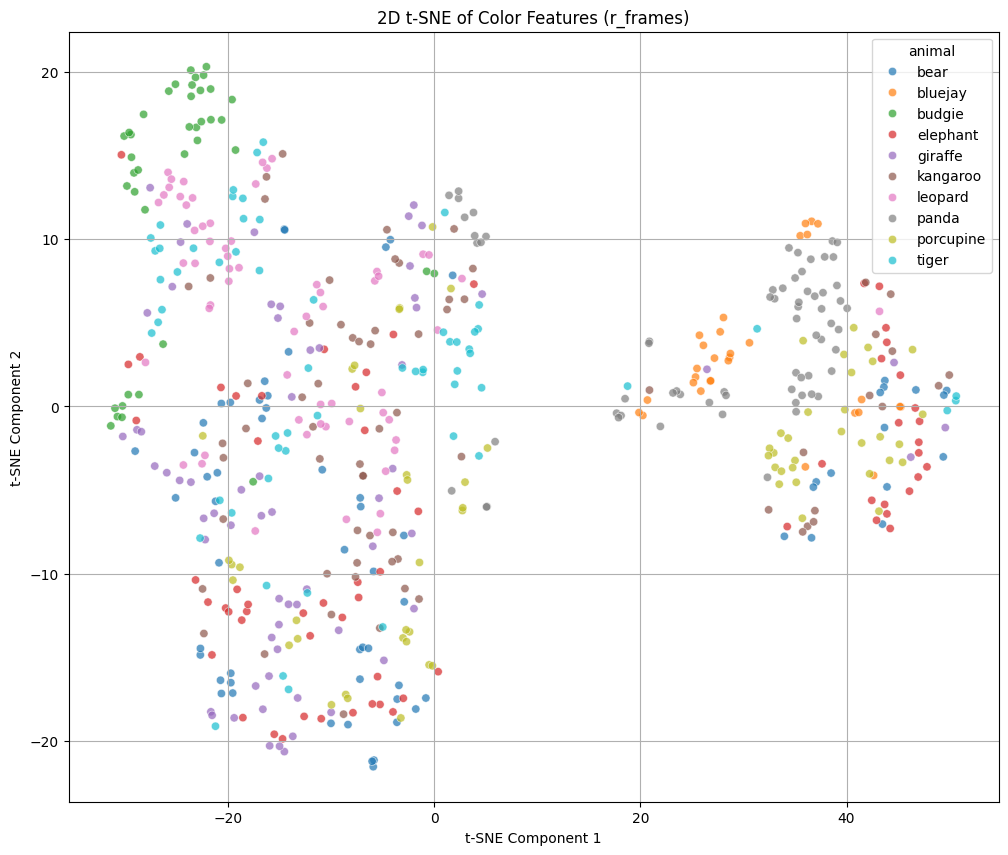

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Import t-SNE
import re # For regular expressions

# Define the path to the feature file
# r_frames_dir đã được set trong pipeline cell → trỏ vào 'multi_r_frames'
feature_output_file = os.path.join(r_frames_dir, 'r_frame_color_features.txt')

# Initialize lists to store data
image_names = []
features_list = []
animal_categories = []

# Read the feature file and parse data
try:
    with open(feature_output_file, 'r') as f:
        for line in f:
            parts = line.strip().split(': ', 1)
            if len(parts) == 2:
                name = parts[0]
                features_str = parts[1]

                # Extract animal category from image name (e.g., r_frame_panda_panda2.png -> panda)
                match = re.search(r'r_frame_([a-zA-Z]+)_', name)
                if match:
                    animal = match.group(1)
                else:
                    animal = 'unknown'

                # Convert feature string to a list of floats
                try:
                    features = eval(features_str) # Using eval for parsing list string, be cautious with untrusted input
                    if isinstance(features, list):
                        image_names.append(name)
                        features_list.append(features)
                        animal_categories.append(animal)
                    else:
                        print(f"Warning: Features for {name} are not a list. Skipping.")
                except (SyntaxError, NameError) as e:
                    print(f"Error parsing features for {name}: {e}. Skipping.")
except FileNotFoundError:
    print(f"Error: Feature file not found at {feature_output_file}")
    exit()

# Convert features list to a numpy array
if not features_list:
    print("No features to visualize.")
else:
    X = np.array(features_list)

    # Apply t-SNE to reduce dimensionality to 2 components
    tsne = TSNE(n_components=2, random_state=42) # Using a random_state for reproducibility
    components = tsne.fit_transform(X)

    # Create a DataFrame for easier plotting with seaborn
    import pandas as pd
    df = pd.DataFrame(data = components, columns = ['tsne_component_1', 'tsne_component_2'])
    df['animal'] = animal_categories
    df['image_name'] = image_names

    # Visualize the t-SNE results
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x="tsne_component_1", y="tsne_component_2",
        hue="animal",
        data=df,
        legend="full",
        alpha=0.7
    )
    plt.title('2D t-SNE of Color Features (r_frames)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()

    # t-SNE does not have an explained_variance_ratio like PCA, so this line is removed or commented out.
    # print("Explained variance ratio by principal components:", pca.explained_variance_ratio_)


In [34]:
pip install plotly

In [35]:
import plotly.express as px

# Visualize the t-SNE results with Plotly for interactivity
fig = px.scatter(
    df,
    x="tsne_component_1",
    y="tsne_component_2",
    color="animal",
    hover_name="image_name", # This will show the image_name on hover
    title='2D t-SNE of Color Features (r_frames) with Hover Information'
)
fig.show()

## 4.3. TEXTURE feature extraction

In [36]:
texture_feature_output_file = os.path.join(r_frames_dir, 'r_frame_texture_features.txt')

with open(texture_feature_output_file, 'w') as f:
    print(f"Extracting texture features from {len(r_frame_files)} r-frames...")
    for r_frame_name in sorted(r_frame_files):
        full_r_frame_path = os.path.join(r_frames_dir, r_frame_name)

        # Load the image (saved as BGRA)
        img_bgra = cv2.imread(full_r_frame_path, cv2.IMREAD_UNCHANGED)

        if img_bgra is None:
            print(f"  -> Warning: Could not load image {r_frame_name}")
            continue

        # Ensure the image has 4 channels (BGRA) and convert to RGBA for extract_ulbp_features
        if img_bgra.shape[2] == 4:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGRA2RGBA)
        else:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGR2RGBA)
            alpha_channel = np.ones(img_rgba.shape[:2], dtype=np.uint8) * 255
            img_rgba = cv2.merge([img_rgba[:,:,0], img_rgba[:,:,1], img_rgba[:,:,2], alpha_channel])

        # Extract texture features
        features = extract_ulbp_features(img_rgba)

        # Write to file
        f.write(f"{r_frame_name}: {features}\n")
    print(f"Uniform LBP (56D) texture feature extraction complete. Results saved to: {texture_feature_output_file}")

Extracting texture features from 581 r-frames...
Uniform LBP (56D) texture feature extraction complete. Results saved to: /content/drive/MyDrive/Last Suffer/da phuong tien/video/multi_r_frames/r_frame_texture_features.txt


### 4.3.1. Visualize Texture Features

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE # Import t-SNE
import re # For regular expressions
import pandas as pd
import plotly.express as px

# Define the path to the texture feature file
# r_frames_dir đã được set trong pipeline cell → trỏ vào 'multi_r_frames'
texture_feature_output_file = os.path.join(r_frames_dir, 'r_frame_texture_features.txt')

# Initialize lists to store data
image_names_texture = []
features_list_texture = []
animal_categories_texture = []

# Read the feature file and parse data
try:
    with open(texture_feature_output_file, 'r') as f:
        for line in f:
            parts = line.strip().split(': ', 1)
            if len(parts) == 2:
                name = parts[0]
                features_str = parts[1]

                # Extract animal category from image name (e.g., r_frame_panda_panda2.png -> panda)
                match = re.search(r'r_frame_([a-zA-Z]+)_', name)
                if match:
                    animal = match.group(1)
                else:
                    animal = 'unknown'

                # Convert feature string to a list of floats
                try:
                    # Safely evaluate the string to a list of floats
                    features = eval(features_str)
                    if isinstance(features, list):
                        image_names_texture.append(name)
                        features_list_texture.append(features)
                        animal_categories_texture.append(animal)
                    else:
                        print(f"Warning: Features for {name} are not a list. Skipping.")
                except (SyntaxError, NameError) as e:
                    print(f"Error parsing features for {name}: {e}. Skipping.")
except FileNotFoundError:
    print(f"Error: Feature file not found at {texture_feature_output_file}")
    exit()

# Convert features list to a numpy array
if not features_list_texture:
    print("No texture features to visualize.")
else:
    X_texture = np.array(features_list_texture)

    # Apply t-SNE to reduce dimensionality to 2 components
    tsne_texture = TSNE(n_components=2, random_state=42) # Using a random_state for reproducibility
    components_texture = tsne_texture.fit_transform(X_texture)

    # Create a DataFrame for easier plotting with seaborn
    df_texture = pd.DataFrame(data = components_texture, columns = ['tsne_component_1', 'tsne_component_2'])
    df_texture['animal'] = animal_categories_texture
    df_texture['image_name'] = image_names_texture

    # Visualize the t-SNE results with Plotly for interactivity
    fig = px.scatter(
        df_texture,
        x="tsne_component_1",
        y="tsne_component_2",
        color="animal",
        hover_name="image_name", # This will show the image_name on hover
        title='2D t-SNE of Texture Features (r_frames) with Hover Information'
    )
    fig.show()

## 4.4. SHAPE feature extraction

In [38]:
shape_feature_output_file = os.path.join(r_frames_dir, 'r_frame_shape_features.txt')

with open(shape_feature_output_file, 'w') as f:
    print(f"Extracting shape features from {len(r_frame_files)} r-frames...")
    for r_frame_name in sorted(r_frame_files):
        full_r_frame_path = os.path.join(r_frames_dir, r_frame_name)

        # Load the image (saved as BGRA)
        img_bgra = cv2.imread(full_r_frame_path, cv2.IMREAD_UNCHANGED)

        if img_bgra is None:
            print(f"  -> Warning: Could not load image {r_frame_name}")
            continue

        # Ensure the image has 4 channels (BGRA) and convert to RGBA for extract_shape_features
        if img_bgra.shape[2] == 4:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGRA2RGBA)
        else:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGR2RGBA)
            alpha_channel = np.ones(img_rgba.shape[:2], dtype=np.uint8) * 255
            img_rgba = cv2.merge([img_rgba[:,:,0], img_rgba[:,:,1], img_rgba[:,:,2], alpha_channel])

        # Extract shape features
        features = extract_shape_features(img_rgba)

        # Write to file
        f.write(f"{r_frame_name}: {features}\n")
    print(f"Shape feature extraction complete. Results saved to: {shape_feature_output_file}")

Extracting shape features from 581 r-frames...
Shape feature extraction complete. Results saved to: /content/drive/MyDrive/Last Suffer/da phuong tien/video/multi_r_frames/r_frame_shape_features.txt


### 4.4.1. Visualize Shape Features

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE # Import t-SNE
import re # For regular expressions
import pandas as pd
import plotly.express as px

# Define the path to the shape feature file
# r_frames_dir đã được set trong pipeline cell → trỏ vào 'multi_r_frames'
shape_feature_output_file = os.path.join(r_frames_dir, 'r_frame_shape_features.txt')

# Initialize lists to store data
image_names_shape = []
features_list_shape = []
animal_categories_shape = []

# Read the feature file and parse data
try:
    with open(shape_feature_output_file, 'r') as f:
        for line in f:
            parts = line.strip().split(': ', 1)
            if len(parts) == 2:
                name = parts[0]
                features_str = parts[1]

                # Extract animal category from image name (e.g., r_frame_panda_panda2.png -> panda)
                match = re.search(r'r_frame_([a-zA-Z]+)_', name)
                if match:
                    animal = match.group(1)
                else:
                    animal = 'unknown'

                # Convert feature string to a list of floats
                try:
                    # Safely evaluate the string to a list of floats
                    features = eval(features_str)
                    if isinstance(features, list):
                        image_names_shape.append(name)
                        features_list_shape.append(features)
                        animal_categories_shape.append(animal)
                    else:
                        print(f"Warning: Features for {name} are not a list. Skipping.")
                except (SyntaxError, NameError) as e:
                    print(f"Error parsing features for {name}: {e}. Skipping.")
except FileNotFoundError:
    print(f"Error: Feature file not found at {shape_feature_output_file}")
    exit()

# Convert features list to a numpy array
if not features_list_shape:
    print("No shape features to visualize.")
else:
    X_shape = np.array(features_list_shape)

    # Apply t-SNE to reduce dimensionality to 2 components
    tsne_shape = TSNE(n_components=2, random_state=42) # Using a random_state for reproducibility
    components_shape = tsne_shape.fit_transform(X_shape)

    # Create a DataFrame for easier plotting with seaborn
    df_shape = pd.DataFrame(data = components_shape, columns = ['tsne_component_1', 'tsne_component_2'])
    df_shape['animal'] = animal_categories_shape
    df_shape['image_name'] = image_names_shape

    # Visualize the t-SNE results with Plotly for interactivity
    fig = px.scatter(
        df_shape,
        x="tsne_component_1",
        y="tsne_component_2",
        color="animal",
        hover_name="image_name", # This will show the image_name on hover
        title='2D t-SNE of Shape Features (r_frames) with Hover Information'
    )
    fig.show()

## 4.5. HOG feature extraction (576D) + PCA → 64D

In [40]:
import cv2
import numpy as np

# --- Trích xuất HOG thô (576D) cho tất cả r-frames ---
hog_raw_feature_file = os.path.join(r_frames_dir, 'r_frame_hog_raw_features.txt')

with open(hog_raw_feature_file, 'w') as f:
    print(f"Extracting HOG (576D) features from {len(r_frame_files)} r-frames...")
    for r_frame_name in sorted(r_frame_files):
        full_r_frame_path = os.path.join(r_frames_dir, r_frame_name)
        img_bgra = cv2.imread(full_r_frame_path, cv2.IMREAD_UNCHANGED)

        if img_bgra is None:
            print(f"  -> Warning: Could not load image {r_frame_name}")
            continue

        if img_bgra.shape[2] == 4:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGRA2RGBA)
        else:
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGR2RGBA)
            alpha_channel = np.ones(img_rgba.shape[:2], dtype=np.uint8) * 255
            img_rgba = cv2.merge([img_rgba[:,:,0], img_rgba[:,:,1], img_rgba[:,:,2], alpha_channel])

        features = extract_hog_features_raw(img_rgba)
        f.write(f"{r_frame_name}: {features.tolist()}\n")

    print(f"HOG (576D) extraction complete → {hog_raw_feature_file}")


Extracting HOG (576D) features from 581 r-frames...
HOG (576D) extraction complete → /content/drive/MyDrive/Last Suffer/da phuong tien/video/multi_r_frames/r_frame_hog_raw_features.txt


In [41]:
import numpy as np
import joblib
from sklearn.decomposition import PCA

# --- Đọc HOG raw từ file ---
hog_names_raw    = []
hog_vectors_raw  = []

with open(hog_raw_feature_file, 'r') as f:
    for line in f:
        parts = line.strip().split(': ', 1)
        if len(parts) != 2:
            continue
        name, feat_str = parts
        try:
            feat = eval(feat_str)
            if isinstance(feat, list):
                if all(v == 0.0 for v in feat):
                    print(f"  [SKIP] {name} - HOG toàn 0 (mask lỗi)")
                    continue
                hog_names_raw.append(name)
                hog_vectors_raw.append(feat)
        except Exception as e:
            print(f"  [WARN] Parse lỗi {name}: {e}")

X_hog_raw = np.array(hog_vectors_raw, dtype=np.float32)
print(f"HOG raw matrix: {X_hog_raw.shape}")   # (N, 576)

# --- Fit PCA 576D → 64D ---
HOG_PCA_DIM = 64
hog_pca = PCA(n_components=HOG_PCA_DIM, random_state=42)
X_hog_pca = hog_pca.fit_transform(X_hog_raw)

explained = hog_pca.explained_variance_ratio_.sum()
print(f"HOG PCA matrix: {X_hog_pca.shape}")
print(f"Phương sai được giải thích (64 thành phần): {explained:.4f} ({explained*100:.1f}%)")

# --- Lưu PCA model để dùng lại ở query ---
hog_pca_model_path = os.path.join(r_frames_dir, 'hog_pca_model.pkl')
joblib.dump(hog_pca, hog_pca_model_path)
print(f"PCA model saved → {hog_pca_model_path}")

# --- Lưu HOG PCA features (64D) ---
hog_pca_feature_file = os.path.join(r_frames_dir, 'r_frame_hog_pca_features.txt')
with open(hog_pca_feature_file, 'w') as f:
    for name, feat in zip(hog_names_raw, X_hog_pca):
        f.write(f"{name}: {feat.tolist()}\n")
print(f"HOG PCA (64D) features saved → {hog_pca_feature_file}")

# --- Lưu vào dict để combine ngay trong session này ---
global hog_pca_features_dict
hog_pca_features_dict = dict(zip(hog_names_raw, X_hog_pca.tolist()))
print(f"hog_pca_features_dict: {len(hog_pca_features_dict)} entries")


HOG raw matrix: (581, 576)
HOG PCA matrix: (581, 64)
Phương sai được giải thích (64 thành phần): 0.6521 (65.2%)
PCA model saved → /content/drive/MyDrive/Last Suffer/da phuong tien/video/multi_r_frames/hog_pca_model.pkl
HOG PCA (64D) features saved → /content/drive/MyDrive/Last Suffer/da phuong tien/video/multi_r_frames/r_frame_hog_pca_features.txt
hog_pca_features_dict: 581 entries


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import re
from sklearn.manifold import TSNE

# --- Đọc HOG PCA features (64D) để visualize ---
hog_names_viz     = []
hog_feats_viz     = []
hog_animals_viz   = []

with open(hog_pca_feature_file, 'r') as f:
    for line in f:
        parts = line.strip().split(': ', 1)
        if len(parts) != 2:
            continue
        name, feat_str = parts
        match = re.search(r'r_frame_([a-zA-Z]+)_', name)
        animal = match.group(1) if match else 'unknown'
        try:
            feat = eval(feat_str)
            if isinstance(feat, list):
                hog_names_viz.append(name)
                hog_feats_viz.append(feat)
                hog_animals_viz.append(animal)
        except Exception as e:
            print(f"Error parsing {name}: {e}")

X_hog_viz = np.array(hog_feats_viz)
if len(X_hog_viz) > 1:
    tsne_hog = TSNE(n_components=2, random_state=42)
    comp_hog = tsne_hog.fit_transform(X_hog_viz)
    df_hog = pd.DataFrame(comp_hog, columns=['tsne_1', 'tsne_2'])
    df_hog['animal']     = hog_animals_viz
    df_hog['image_name'] = hog_names_viz

    fig = px.scatter(df_hog, x='tsne_1', y='tsne_2', color='animal',
                     hover_name='image_name',
                     title='2D t-SNE of HOG PCA (64D) Features')
    fig.show()
else:
    print("Không đủ mẫu để visualize.")


## 4.6. Combine All Features

In [44]:
import numpy as np
import os
from sklearn.preprocessing import RobustScaler

# ── Độ dài các nhóm feature ──────────────────────────────────────────────────
color_moment_len  = 9
color_hist_len    = 12 * 4 * 4     # 192
color_feature_len = color_moment_len + color_hist_len  # 201
texture_feature_len = 56            # Uniform LBP 56D
shape_feature_len   = 7
hog_pca_feature_len = 64            # HOG 576D → PCA 64D

# Define file paths
color_feature_file    = os.path.join(r_frames_dir, 'r_frame_color_features.txt')
texture_feature_file  = os.path.join(r_frames_dir, 'r_frame_texture_features.txt')
shape_feature_file    = os.path.join(r_frames_dir, 'r_frame_shape_features.txt')
hog_pca_feature_file  = os.path.join(r_frames_dir, 'r_frame_hog_pca_features.txt')
combined_feature_file = os.path.join(r_frames_dir, 'r_frame_features.txt')

all_features = {}

def parse_feature_file(file_path, feature_type):
    """Đọc file feature, bỏ qua dòng có vector toàn 0 (mask lỗi)."""
    try:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split(': ', 1)
                if len(parts) != 2:
                    continue
                name, features_str = parts
                try:
                    features = eval(features_str)
                    if not isinstance(features, list):
                        continue
                    if all(v == 0.0 for v in features):
                        print(f"  [SKIP] {name} - {feature_type} feature toàn 0 (mask lỗi)")
                        continue
                    if name not in all_features:
                        all_features[name] = {'color': [], 'texture': [], 'shape': [], 'hog_pca': []}
                    all_features[name][feature_type] = features
                except Exception as e:
                    print(f"  [WARN] Parse lỗi {name}: {e}")
    except FileNotFoundError:
        print(f"[ERROR] File không tồn tại: {file_path}")

parse_feature_file(color_feature_file,   'color')
parse_feature_file(texture_feature_file, 'texture')
parse_feature_file(shape_feature_file,   'shape')
parse_feature_file(hog_pca_feature_file, 'hog_pca')

# Chỉ giữ ảnh có đủ cả 4 loại feature
valid_names = [n for n in sorted(all_features) if
               all_features[n]['color'] and
               all_features[n]['texture'] and
               all_features[n]['shape'] and
               all_features[n]['hog_pca']]
print(f"Số ảnh hợp lệ để combine: {len(valid_names)}")

image_names_ordered       = []
color_moment_features_raw = []
color_hist_features_raw   = []
texture_features_raw      = []
shape_features_raw        = []
hog_pca_features_raw      = []

for name in valid_names:
    image_names_ordered.append(name)
    cf = all_features[name]['color']
    color_moment_features_raw.append(cf[:color_moment_len])
    color_hist_features_raw.append(cf[color_moment_len:color_feature_len])
    texture_features_raw.append(all_features[name]['texture'])
    shape_features_raw.append(all_features[name]['shape'])
    hog_pca_features_raw.append(all_features[name]['hog_pca'])

color_moment_features_array = np.array(color_moment_features_raw)
color_hist_features_array   = np.array(color_hist_features_raw)
texture_features_array      = np.array(texture_features_raw)
shape_features_array        = np.array(shape_features_raw)
hog_pca_features_array      = np.array(hog_pca_features_raw)

# ── Scaling ────────────────────────────────────────────────────────────────
# Histogram đã L1-normalize → KHÔNG scale thêm
# HOG PCA đã được PCA whitening → RobustScaler thêm để đồng nhất khoảng
global color_moment_scaler, texture_scaler, shape_scaler, hog_pca_scaler
color_moment_scaler = RobustScaler()
texture_scaler      = RobustScaler()
shape_scaler        = RobustScaler()
hog_pca_scaler      = RobustScaler()

def safe_scale(scaler, arr):
    return scaler.fit_transform(arr) if len(arr) > 0 else np.array([])

scaled_color_moment = safe_scale(color_moment_scaler, color_moment_features_array)
scaled_color_hist   = color_hist_features_array          # Không scale
scaled_texture      = safe_scale(texture_scaler,      texture_features_array)
scaled_shape        = safe_scale(shape_scaler,        shape_features_array)
scaled_hog_pca      = safe_scale(hog_pca_scaler,     hog_pca_features_array)

# ── Ghép & lưu ────────────────────────────────────────────────────────────
scaled_combined_features_list = []
for i in range(len(image_names_ordered)):
    row = []
    if len(scaled_color_moment) > 0: row.extend(scaled_color_moment[i].tolist())
    if len(scaled_color_hist)   > 0: row.extend(scaled_color_hist[i].tolist())
    if len(scaled_texture)      > 0: row.extend(scaled_texture[i].tolist())
    if len(scaled_shape)        > 0: row.extend(scaled_shape[i].tolist())
    if len(scaled_hog_pca)      > 0: row.extend(scaled_hog_pca[i].tolist())
    scaled_combined_features_list.append(row)

with open(combined_feature_file, 'w') as f:
    print(f"Saving combined features → {combined_feature_file}")
    for i, name in enumerate(image_names_ordered):
        f.write(f"{name}: {scaled_combined_features_list[i]}\n")

total_dim = len(scaled_combined_features_list[0]) if scaled_combined_features_list else 0
print(f"Done. Total feature dim per image: {total_dim}")
print(f"  Color moments  : {color_moment_len}D  (RobustScaled)")
print(f"  Color histogram: {color_hist_len}D  (L1-normalized, no extra scale)")
print(f"  Texture (ULBP) : {texture_feature_len}D  (RobustScaled)")
print(f"  Shape          : {shape_feature_len}D  (RobustScaled)")
print(f"  HOG PCA        : {hog_pca_feature_len}D  (RobustScaled, từ 576D HOG)")
print(f"  ──────────────────────────────────────")
print(f"  TOTAL          : {total_dim}D")


Số ảnh hợp lệ để combine: 581
Saving combined features → /content/drive/MyDrive/Last Suffer/da phuong tien/video/multi_r_frames/r_frame_features.txt
Done. Total feature dim per image: 328
  Color moments  : 9D  (RobustScaled)
  Color histogram: 192D  (L1-normalized, no extra scale)
  Texture (ULBP) : 56D  (RobustScaled)
  Shape          : 7D  (RobustScaled)
  HOG PCA        : 64D  (RobustScaled, từ 576D HOG)
  ──────────────────────────────────────
  TOTAL          : 328D


# 5. query

## 5.1. QUERY FOLDER

In [45]:
import os

query_folder_path = os.path.join(video_path, 'query')

if os.path.exists(query_folder_path):
    print(f"Contents of '{query_folder_path}':")
    for item in os.listdir(query_folder_path):
        print(item)
else:
    print(f"The folder '{query_folder_path}' does not exist.")

Contents of '/content/drive/MyDrive/Last Suffer/da phuong tien/video/query':
query_tiger1.jpg
query_kangaroo1.jpg
query_kangaroo2.jpg
query_bluejay1.jpg
query_leopard1.jpg
query_panda1.jpg
query_porcupine1.jpg
query_giraffe1.jpg
query_elephant1.jpg
query_bluejay2.jpg
query_bear1.jpg
query_bear2.jpg
query_porcupine2.jpg
query_leopard2.jpg
query_tiger2.jpg
query_tiger3.jpg


## 5.2. QUERY using new Color Moments + quantized HSV

### 5.2.1. Image Input

In [105]:
import io
import joblib
import numpy as np
from IPython.display import Image, display

query_image_name = input("Please enter the name of the query image from the 'video/query' folder (e.g., query_panda1.jpg): ")

query_folder_path     = os.path.join(video_path, 'query')
full_query_image_path = os.path.join(query_folder_path, query_image_name)
print(f"Selected query image: {full_query_image_path}")

raw_query_image_bgr  = cv2.imread(full_query_image_path, cv2.IMREAD_UNCHANGED)
query_feature_vector = None

if raw_query_image_bgr is None:
    print(f"[ERROR] Không load được ảnh: {query_image_name}")
else:
    # ── Hiển thị ảnh gốc ────────────────────────────────────────────────────
    print("\nDisplaying Raw Query Image:")
    _, buffer = cv2.imencode('.png', raw_query_image_bgr)
    display(Image(io.BytesIO(buffer).getvalue()))

    # ── Đảm bảo đầu vào là BGR 3 kênh ──────────────────────────────────────
    if raw_query_image_bgr.ndim == 2:
        raw_query_image_bgr = cv2.cvtColor(raw_query_image_bgr, cv2.COLOR_GRAY2BGR)
    elif raw_query_image_bgr.shape[2] == 4:
        raw_query_image_bgr = cv2.cvtColor(raw_query_image_bgr, cv2.COLOR_BGRA2BGR)

    # ── Step 2: Segment trực tiếp trên ảnh gốc (pipeline mới, không normalize trước) ──
    print("Segmenting query object from background...")
    segmented_query_image_rgba, seg_valid = segment_object_from_bg(raw_query_image_bgr)

    if not seg_valid:
        print("[WARN] Segmentation chất lượng thấp — kết quả query có thể kém chính xác.")

    print("\nDisplaying Segmented Query Image:")
    _, seg_buffer = cv2.imencode('.png', cv2.cvtColor(segmented_query_image_rgba, cv2.COLOR_RGBA2BGRA))
    display(Image(io.BytesIO(seg_buffer).getvalue()))

    # ── Step 3: Normalize trên ROI đã crop (pipeline mới) ───────────────────
    print("Normalizing query image on ROI...")
    normalized_query_rgba = normalize_image_on_roi(segmented_query_image_rgba, target_size=(512, 512))

    if normalized_query_rgba is None:
        print("[ERROR] normalize_image_on_roi thất bại — ROI rỗng.")
    else:
        # ── Step 4: Trích feature ────────────────────────────────────────────
        print("\nExtracting color features for query...")
        query_color_features   = extract_color_features_128bin(normalized_query_rgba)

        print("Extracting texture features for query...")
        query_texture_features = extract_ulbp_features(normalized_query_rgba)

        print("Extracting shape features for query...")
        query_shape_features   = extract_shape_features(normalized_query_rgba)

        # ── Step 5: HOG 576D → PCA 64D ──────────────────────────────────────
        print("Extracting HOG features for query (576D)...")
        query_hog_raw = extract_hog_features_raw(normalized_query_rgba)  # (576,)

        print("Applying PCA (576D → 64D)...")
        hog_pca_model_path = os.path.join(r_frames_dir, 'hog_pca_model.pkl')
        hog_pca_loaded     = joblib.load(hog_pca_model_path)
        query_hog_pca      = hog_pca_loaded.transform(query_hog_raw.reshape(1, -1))[0]  # (64,)

        # ── Ghép thành vector ────────────────────────────────────────────────
        query_feature_vector = np.array(
            query_color_features + query_texture_features + query_shape_features + query_hog_pca.tolist()
        ).reshape(1, -1)

        print(f"\nQuery feature vector shape: {query_feature_vector.shape}")
        print(f"  Color  ({len(query_color_features)}D) + Texture ({len(query_texture_features)}D) "
              f"+ Shape ({len(query_shape_features)}D) + HOG_PCA ({len(query_hog_pca)}D)")


Please enter the name of the query image from the 'video/query' folder (e.g., query_panda1.jpg): d
Selected query image: /content/drive/MyDrive/Last Suffer/da phuong tien/video/query/d
[ERROR] Không load được ảnh: d


### 5.2.2. Get result

In [106]:
import matplotlib.pyplot as plt
import numpy as np
import re

if query_feature_vector is not None:
    # ── Cập nhật dim ─────────────────────────────────────────────────────────
    color_moment_len    = 9
    color_hist_len      = 12 * 4 * 4   # 192
    color_feature_len   = color_moment_len + color_hist_len   # 201
    texture_feature_len = 56
    shape_feature_len   = 7
    hog_pca_feature_len = 64

    e0 = color_moment_len
    e1 = color_feature_len
    e2 = e1 + texture_feature_len
    e3 = e2 + shape_feature_len
    e4 = e3 + hog_pca_feature_len

    # ── Weights ───────────────────────────────────────────────────────────────
    w_color_moments    = 0.25
    w_color_histograms = 0.45
    w_texture          = 0.12
    w_shape            = 0.12
    w_hog_pca          = 0.12

    dataset_image_names    = []
    dataset_feature_vectors = []

    print(f"Loading combined features from {combined_feature_file}...")
    try:
        with open(combined_feature_file, 'r') as f:
            for line in f:
                parts = line.strip().split(': ', 1)
                if len(parts) == 2:
                    name, features_str = parts
                    try:
                        features = eval(features_str)
                        if isinstance(features, list):
                            dataset_image_names.append(name)
                            dataset_feature_vectors.append(features)
                    except Exception as e:
                        print(f"  [WARN] Parse lỗi {name}: {e}")
    except FileNotFoundError:
        print(f"[ERROR] File không tồn tại: {combined_feature_file}")
        exit()

    if not dataset_feature_vectors:
        print("Không có feature nào để query.")
    else:
        dataset_feature_matrix = np.array(dataset_feature_vectors)
        print(f"Dataset matrix shape: {dataset_feature_matrix.shape}")

        # ── Scale query features bằng đúng scaler đã fit ─────────────────────
        raw_q_cm   = query_feature_vector[0, :e0].reshape(1, -1)
        raw_q_hist = query_feature_vector[0, e0:e1].reshape(1, -1)
        raw_q_tex  = query_feature_vector[0, e1:e2].reshape(1, -1)
        raw_q_shp  = query_feature_vector[0, e2:e3].reshape(1, -1)
        raw_q_hog  = query_feature_vector[0, e3:e4].reshape(1, -1)

        scaled_q_cm   = color_moment_scaler.transform(raw_q_cm)[0]
        scaled_q_hist = raw_q_hist[0]
        scaled_q_tex  = texture_scaler.transform(raw_q_tex)[0]
        scaled_q_shp  = shape_scaler.transform(raw_q_shp)[0]
        scaled_q_hog  = hog_pca_scaler.transform(raw_q_hog)[0]

        db_cm   = dataset_feature_matrix[:, :e0]
        db_hist = dataset_feature_matrix[:, e0:e1]
        db_tex  = dataset_feature_matrix[:, e1:e2]
        db_shp  = dataset_feature_matrix[:, e2:e3]
        db_hog  = dataset_feature_matrix[:, e3:e4]

        # ── Hybrid Metric (giữ nguyên như pipeline cũ) ────────────────────────
        eps      = 1e-10
        chi2_dist = 0.5 * np.sum(
            (db_hist - scaled_q_hist) ** 2 / (db_hist + scaled_q_hist + eps), axis=1)
        sim_chi2  = 1.0 / (1.0 + chi2_dist)

        sim_cm  = 1.0 / (1.0 + np.linalg.norm(db_cm  - scaled_q_cm,  axis=1))
        sim_tex = 1.0 / (1.0 + np.linalg.norm(db_tex - scaled_q_tex, axis=1))
        sim_shp = 1.0 / (1.0 + np.linalg.norm(db_shp - scaled_q_shp, axis=1))
        sim_hog = 1.0 / (1.0 + np.linalg.norm(db_hog - scaled_q_hog, axis=1))

        frame_similarities = (
            w_color_moments    * sim_cm   +
            w_color_histograms * sim_chi2 +
            w_texture          * sim_tex  +
            w_shape            * sim_shp  +
            w_hog_pca          * sim_hog
        )  # shape (N_frames,)

        # ════════════════════════════════════════════════════════════════════
        # MULTI-FRAME RANKING: d(Q, Video) = MAX similarity trên các r-frames
        # Tương đương min-distance → chọn frame nào "khớp nhất" với query
        # Nhóm theo video gốc: tên file dạng r_frame_{animal}_{video_stem}_f{idx}.png
        # ════════════════════════════════════════════════════════════════════
        video_best_sim   = {}   # video_id → best similarity score
        video_best_frame = {}   # video_id → tên frame có score cao nhất

        for sim_score, frame_name in zip(frame_similarities, dataset_image_names):
            # Tách video_id = phần tên không có "_f{idx}.png"
            # Ví dụ: r_frame_panda_panda2_f01.png → video_id = r_frame_panda_panda2
            match = re.match(r"(.+)_f\d{2}\.png$", frame_name)
            video_id = match.group(1) if match else frame_name  # fallback nếu tên cũ

            if video_id not in video_best_sim or sim_score > video_best_sim[video_id]:
                video_best_sim[video_id]   = sim_score
                video_best_frame[video_id] = frame_name

        # Sắp xếp video theo score giảm dần
        ranked_videos = sorted(video_best_sim.items(), key=lambda x: x[1], reverse=True)

        # ── Hiển thị Top 10 (theo video) ─────────────────────────────────────
        print(f"\n--- Top 10 Most Similar VIDEOS (Multi-frame, Min-Distance Ranking) ---")
        print(f"Metric: Chi-Squared (Hist) + L2 (CM, LBP, Shape, HOG-PCA)")
        print(f"Weights: CM={w_color_moments}, Hist={w_color_histograms}, "
              f"Tex={w_texture}, Shape={w_shape}, HOG_PCA={w_hog_pca}")
        print(f"Tổng số r-frames trong DB: {len(dataset_image_names)}")
        print(f"Tổng số video duy nhất   : {len(ranked_videos)}")

        num_to_display = min(10, len(ranked_videos))
        fig, axes = plt.subplots(1, num_to_display, figsize=(20, 5))
        if num_to_display == 1:
            axes = [axes]
        axes = list(axes)

        for rank, (video_id, best_score) in enumerate(ranked_videos[:num_to_display]):
            best_frame_name = video_best_frame[video_id]
            full_image_path = os.path.join(r_frames_dir, best_frame_name)
            img_to_display  = cv2.imread(full_image_path, cv2.IMREAD_UNCHANGED)
            short_name      = video_id[8:] if video_id.startswith("r_frame_") else video_id

            if img_to_display is not None:
                img_rgb = cv2.cvtColor(img_to_display, cv2.COLOR_BGRA2RGBA)
                axes[rank].imshow(img_rgb)
                axes[rank].set_title(
                    f"Rank {rank+1}\nSim: {best_score:.3f}\n{short_name}", fontsize=7)
                axes[rank].axis('off')

        for j in range(num_to_display, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
else:
    print("Query feature vector không tồn tại. Không thể query.")


Query feature vector không tồn tại. Không thể query.


In [88]:
print("Query Feature Vector:")
display(query_feature_vector)

Query Feature Vector:


array([[ 2.40236378e+01,  4.00430832e+01, -3.66101593e-01,
         5.26957474e+01,  4.78987007e+01,  1.78164387e+00,
         1.16056389e+02,  5.41060410e+01, -2.14311704e-01,
         2.65320707e-02,  6.09013587e-02,  6.88419044e-02,
         2.02209670e-02,  8.19489639e-03,  6.37310222e-02,
         9.46904048e-02,  5.28574828e-03,  3.05222161e-03,
         1.26778474e-02,  6.09649438e-03,  0.00000000e+00,
         1.53405929e-03,  7.94849348e-06,  0.00000000e+00,
         0.00000000e+00,  1.15412129e-02,  3.44010815e-02,
         3.73817645e-02,  1.52134169e-02,  7.66234752e-03,
         1.34091089e-02,  1.37270484e-02,  1.81225652e-03,
         6.43827952e-03,  2.54351785e-03,  7.31261389e-04,
         0.00000000e+00,  5.95342182e-03,  8.42540292e-04,
         0.00000000e+00,  0.00000000e+00,  8.76718853e-03,
         3.67856286e-02,  1.29798902e-02,  9.61767684e-04,
         7.32056238e-03,  7.45568704e-03,  2.78197258e-04,
         0.00000000e+00,  7.79747218e-03,  6.99467433e-0